In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年06月23日 11时36分52秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("../tests/data/bifurcating.h5ad")
sc.pp.subsample(adata, n_obs=100)
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
# sc.pp.subsample(fadata, n_obs=100) # 此时，subsample会导致fadata.uns["cfe"], fadata.cfe_dict不是同一个对象，不能放在后面
fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]

fadata

AnnData object with n_obs × n_vars = 100 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["sA -> sB", "sB -> sBmid"],
        ["sB -> sBmid", "sBmid -> sC"],
        ["sB -> sBmid", "sBmid -> sD"],
        ["sBmid -> sC", "sC -> sEndC"],
        ["sBmid -> sD", "sD -> sEndD"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network, cluster_key="lineage")

AnnData object with n_obs × n_vars = 100 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD', 'milestone_color', 'milestone'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_emb', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

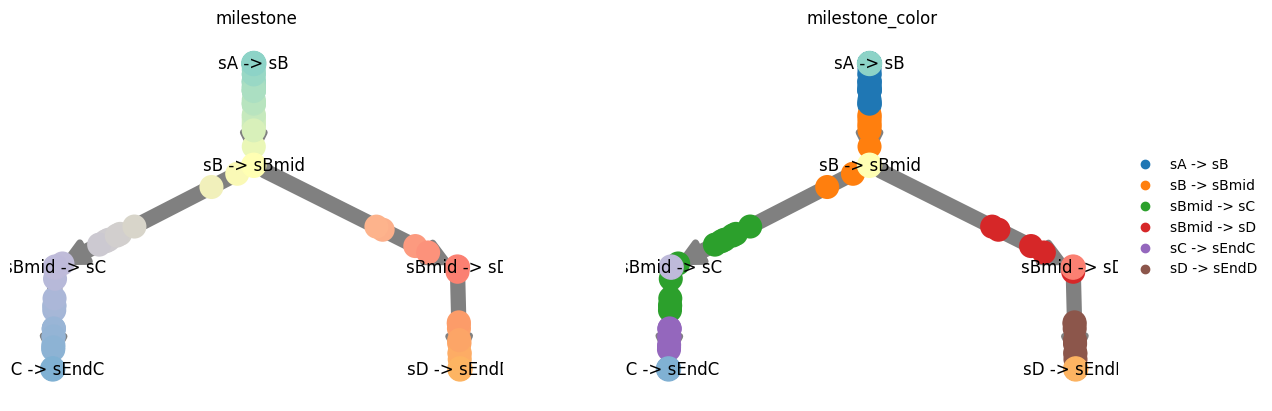

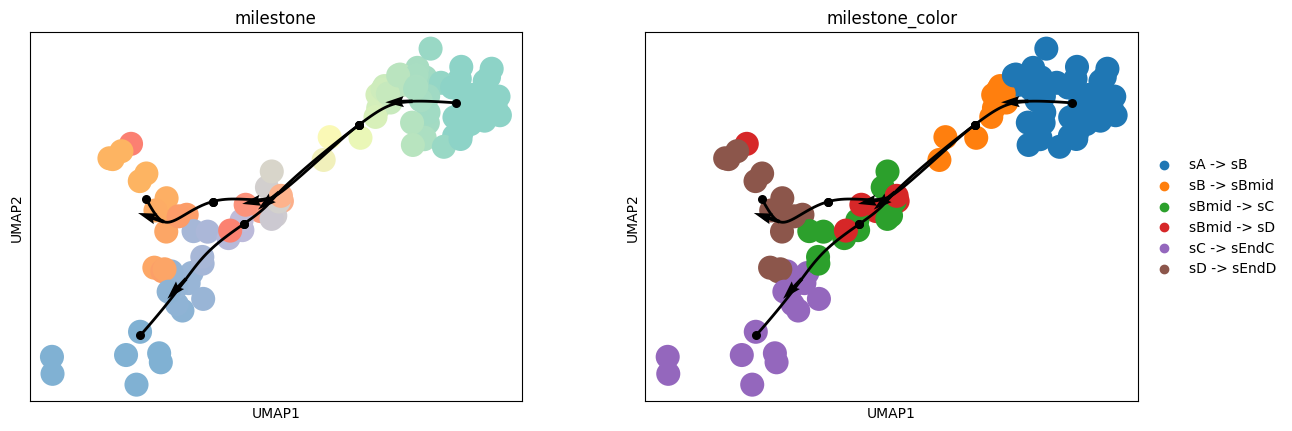

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

## 新绘图函数绘制时会保存到fadata.uns["cfe"]["ref"]["trajectory_embedding"]里, 暂时绘制里程碑网络

<Axes: title={'center': 'milestone_color'}, xlabel='emb1', ylabel='emb2'>

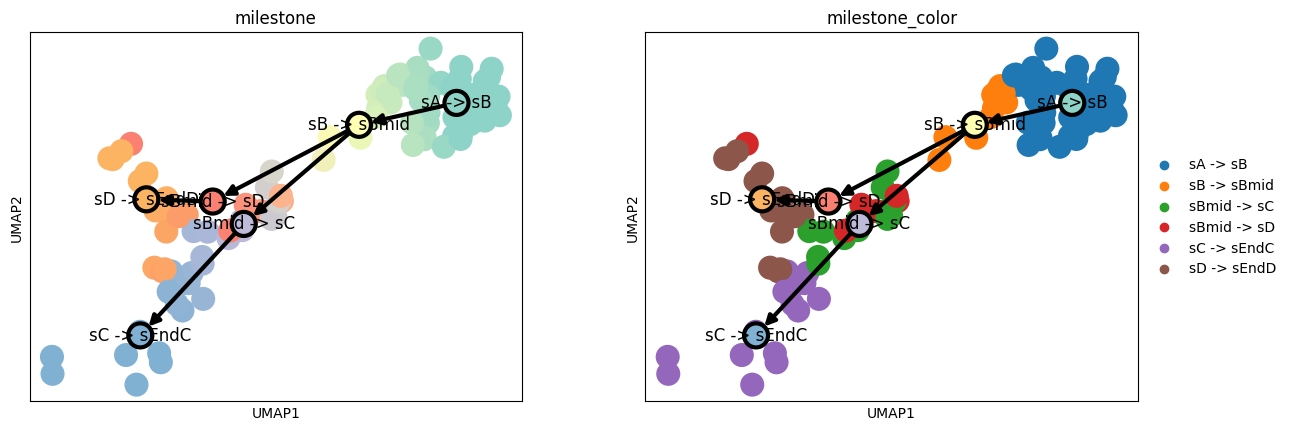

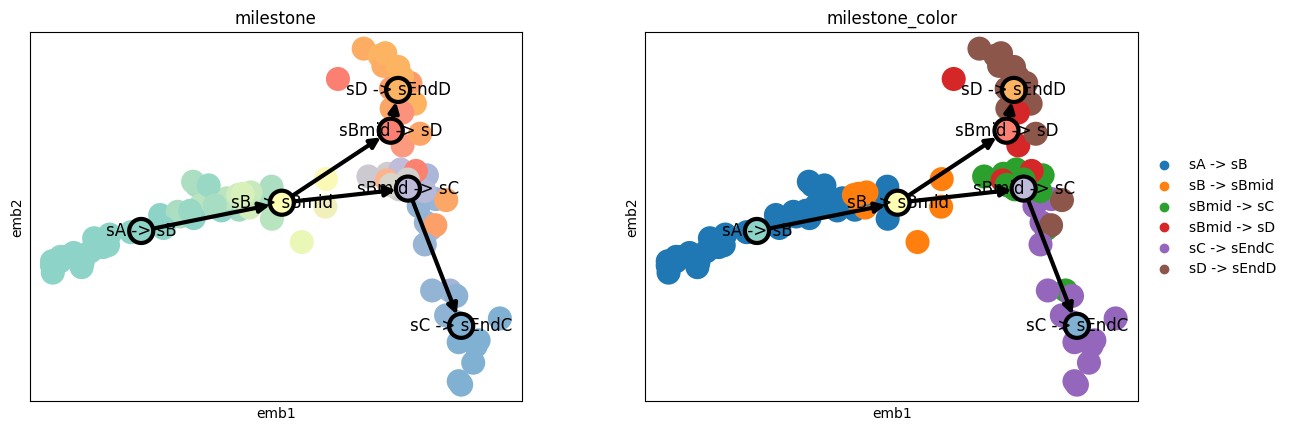

In [5]:
cluster_key = "lineage"
cfe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key_list)
cfe.plot.plot_trajectory_new(fadata, basis="emb", curve=False, color=cluster_key_list)

In [6]:
# trajectory_embedding = fadata.get_trajectory_embedding("umap")

# trajectory_embedding["wp_segments"]

In [7]:
# trajectory_embedding["milestone_positions"]

In [8]:
# # 保存
# fadata.obs = fadata.obs[["lineage", "global_time"]] # 保存obs中两列关键属性
# fadata.write_h5ad("bifurcating_fadata.h5ad") # 保存时__dict__会修改category为int

# # scanpy原生读取与cfe读取
# adata_new = sc.read_h5ad("bifurcating_fadata.h5ad")
# fadata_new = cfe.data.read_h5ad("bifurcating_fadata.h5ad")
# type(adata_new), type(fadata_new)

# import numpy as np

# # 提取里程碑轨迹，
# trajectory_embedding = adata_new.uns["cfe"]["trajectory_history_dict"]["ref"]["trajectory_embedding"]["emb"]
# milestone_positions = trajectory_embedding["milestone_positions"]
# milestone_positions

# def extract_coords(group_item):
#     from_row = group_item[group_item["percentage"] == 0].iloc[0]
#     to_row = group_item[group_item["percentage"] == 1].iloc[0]
#     from_coord = from_row[["comp_1", "comp_2"]].astype(float).values
#     to_coord = to_row[["comp_1", "comp_2"]].astype(float).values
#     return [from_coord, to_coord]

# trajectory_embedding_array = milestone_positions.groupby("group").apply(extract_coords).values.tolist()
# trajectory_embedding_array = np.array(trajectory_embedding_array)
# trajectory_embedding_array

## 额外方法结果添加

[2025年06月23日 11时36分56秒] INFO     Loaded function: <function cf_paga at 0x7ed591c93370> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7ed591bbb9a0>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


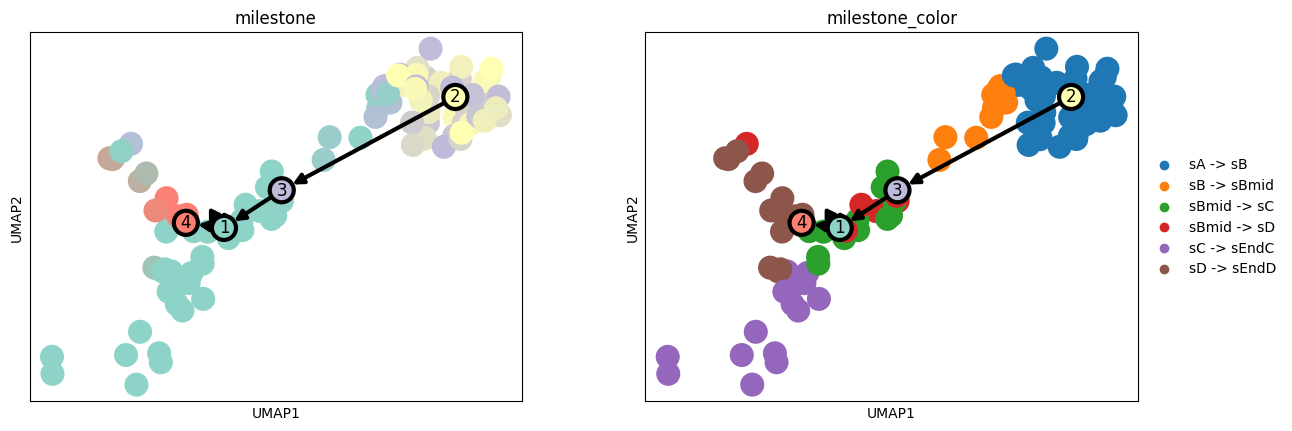

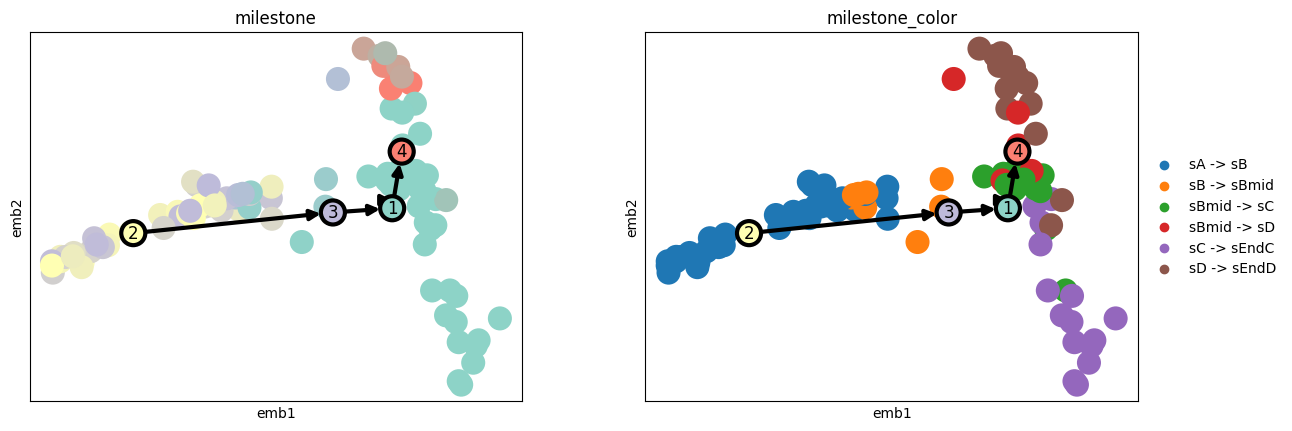

In [9]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    # cfe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key) 单独cluster_key会出错
    cfe.plot.plot_trajectory_new(fadata, basis="umap", curve=False, color=cluster_key_list)
    cfe.plot.plot_trajectory_new(fadata, basis="emb", curve=False, color=cluster_key_list)

In [10]:
fadata.obs = fadata.obs[["lineage", "global_time"]]
fadata.write_h5ad("bifurcating_fadata.h5ad")

transfer milestone color from tuple to list
transfer 'ref' to dict
transfer '20250623_113656__paga-python_function__UwFv3XUZgV' to dict


In [11]:
# 打印二层结构
import json


def print_dict_keys(d, depth=1, max_depth=3):
    if depth > max_depth:
        return
    for key, value in d.items():
        print(f"{'    '* (depth - 1)}{key}")
        if isinstance(value, dict):
            print_dict_keys(value, depth + 1, max_depth)
        elif isinstance(value, (list, tuple)) and any(isinstance(x, dict) for x in value):
            for item in value:
                if isinstance(item, dict):
                    print_dict_keys(item, depth + 1, max_depth)


# 打印cfe轨迹的字典键结构
print_dict_keys(fadata.uns["cfe"])

prior_information
    start_id
    groups_id
trajectory_history_dict
    ref
        milestone_wrapper
        raw_wrapper_dict
        trajectory_embedding
        waypoint_wrapper
    20250623_113656__paga-python_function__UwFv3XUZgV
        milestone_wrapper
        raw_wrapper_dict
        trajectory_embedding
        waypoint_wrapper
model_name


In [40]:
df = adata.uns["cfe"]["trajectory_history_dict"]["ref"]

In [12]:
fadata.uns["cfe"]["trajectory_history_dict"].keys()

dict_keys(['ref', '20250623_113656__paga-python_function__UwFv3XUZgV'])

In [52]:
fadata.uns["cfe"]["trajectory_history_dict"]["ref"]["trajectory_embedding"]["umap"].keys()

dict_keys(['wp_segments', 'milestone_positions'])

In [46]:
import json
import numpy as np
import pandas as pd
from json import JSONEncoder


class CustomJSONEncoder(JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()  # 将 numpy 数组转为 Python list
        elif isinstance(obj, pd.DataFrame):
            return obj.to_dict(orient="records")  # 将 DataFrame 转为字典列表
        elif isinstance(obj, (np.int64, np.int32, np.float64, np.float32)):
            return int(obj) if isinstance(obj, (np.int64, np.int32)) else float(obj)
        if isinstance(obj, (np.bool_, bool)):
            return bool(obj)
        return JSONEncoder.default(self, obj)


# 示例数据
data = fadata.uns["cfe"]

# 使用自定义编码器进行 JSON 序列化
json_str = json.dumps(data, cls=CustomJSONEncoder, indent=2)
print(json_str)

{
  "prior_information": {
    "start_id": "cell_000",
    "groups_id": [
      "sC -> sEndC",
      "sA -> sB",
      "sD -> sEndD",
      "sD -> sEndD",
      "sA -> sB",
      "sA -> sB",
      "sA -> sB",
      "sBmid -> sD",
      "sB -> sBmid",
      "sA -> sB",
      "sBmid -> sC",
      "sC -> sEndC",
      "sA -> sB",
      "sD -> sEndD",
      "sA -> sB",
      "sA -> sB",
      "sA -> sB",
      "sA -> sB",
      "sBmid -> sC",
      "sB -> sBmid",
      "sBmid -> sC",
      "sC -> sEndC",
      "sA -> sB",
      "sBmid -> sC",
      "sBmid -> sD",
      "sA -> sB",
      "sA -> sB",
      "sC -> sEndC",
      "sB -> sBmid",
      "sA -> sB",
      "sA -> sB",
      "sB -> sBmid",
      "sA -> sB",
      "sA -> sB",
      "sC -> sEndC",
      "sD -> sEndD",
      "sBmid -> sC",
      "sC -> sEndC",
      "sBmid -> sD",
      "sBmid -> sC",
      "sA -> sB",
      "sA -> sB",
      "sC -> sEndC",
      "sBmid -> sD",
      "sB -> sBmid",
      "sD -> sEndD",
      "sBmid -> s

In [ ]:
te = fadata.uns["cfe"]["trajectory_history_dict"]["ref"]["trajectory_embedding"]
for ename in te.keys():
    cell_embedding = fadata.obsm[f"X_{ename}"]
    wp_segments = te[ename]["wp_segments"]
    milestone_positions = te[ename]["milestone_positions"]
    wp_segments[""]

    # TODO:  scale wp_segments and milestone_positions with cell embedding parameters
    te[ename] = {
        "wp_segments": wp_segments,
        "milestone_positions": milestone_positions,
    }
    wp_segments = wp_segments[
        [
            "comp1",
            "comp2",
        ]
    ]
    milestone_positions

te

{'umap': {'wp_segments':         comp_1     comp_2                             waypoint_id  \
  0    10.138438  10.567683   MILESTONE_BEGIN_WsA -> sB_sB -> sBmid   
  1    10.083116  10.571022                                      W2   
  2    10.023910  10.574492                                      W3   
  3     9.960663  10.578091                                      W4   
  4     9.893238  10.581810                                      W5   
  ..         ...        ...                                     ...   
  203  -2.492641   7.258985                                    W204   
  204  -2.529983   7.310870                                    W205   
  205  -2.566390   7.362358                                    W206   
  206  -2.601838   7.413220                                    W207   
  207  -2.621661   7.441934  MILESTONE_END_WsBmid -> sD_sD -> sEndD   
  
      milestone_id         from           to  percentage  \
  0       sA -> sB     sA -> sB  sB -> sBmid    0.000000   
  

In [63]:
ename = "umap"
cell_embedding = fadata.obsm[f"X_{ename}"]
cell_embedding

array([[-0.7631105 ,  5.0522966 ,  5.4146557 ],
       [ 8.960391  ,  9.920403  ,  8.177811  ],
       [-0.96300817,  6.941523  ,  6.08498   ],
       [-2.294177  ,  5.225944  ,  6.192029  ],
       [10.054533  , 10.10109   ,  8.3231125 ],
       [11.659926  , 10.657355  ,  7.038597  ],
       [10.273583  , 11.350242  ,  6.9792933 ],
       [ 2.9540296 ,  7.384162  ,  9.248109  ],
       [ 6.917223  , 10.401036  ,  7.919511  ],
       [ 8.857951  , 11.394577  ,  6.963058  ],
       [ 2.5838213 ,  7.1070557 ,  7.7342286 ],
       [-0.3086304 ,  5.3567405 ,  6.629328  ],
       [10.040601  ,  9.495907  ,  7.9091964 ],
       [-1.9723475 ,  7.091131  ,  5.4667044 ],
       [11.924012  , 10.168713  ,  8.101722  ],
       [11.016587  , 10.495468  ,  8.034348  ],
       [ 9.498748  , 11.219638  ,  6.845288  ],
       [11.209838  , 10.409317  ,  7.8844075 ],
       [-0.3206484 ,  5.5732594 ,  7.035418  ],
       [ 6.187712  ,  9.436937  ,  6.897481  ],
       [-0.6813602 ,  6.411094  ,  5.817

In [69]:
milestone_positions = te["umap"]["milestone_positions"]
# milestone_positions = milestone_positions[["comp_1", "comp_2", ]]
milestone_positions

,comp_1,comp_2,waypoint_id,milestone_id,from,to,percentage,group,arrow
0,10.138438,10.567683,MILESTONE_BEGIN_WsA -> sB_sB -> sBmid,sA -> sB,sA -> sB,sB -> sBmid,0.0,sA -> sB---sB -> sBmid,False
40,6.128707,9.857426,MILESTONE_END_WsA -> sB_sB -> sBmid,sB -> sBmid,sA -> sB,sB -> sBmid,1.0,sA -> sB---sB -> sBmid,False
41,6.128707,9.857426,MILESTONE_BEGIN_WsB -> sBmid_sBmid -> sC,sB -> sBmid,sB -> sBmid,sBmid -> sC,0.0,sB -> sBmid---sBmid -> sC,False
84,1.384150,6.643654,MILESTONE_END_WsB -> sBmid_sBmid -> sC,sBmid -> sC,sB -> sBmid,sBmid -> sC,1.0,sB -> sBmid---sBmid -> sC,False
85,6.128707,9.857426,MILESTONE_BEGIN_WsB -> sBmid_sBmid -> sD,sB -> sBmid,sB -> sBmid,sBmid -> sD,0.0,sB -> sBmid---sBmid -> sD,False
129,0.105585,7.369748,MILESTONE_END_WsB -> sBmid_sBmid -> sD,sBmid -> sD,sB -> sBmid,sBmid -> sD,1.0,sB -> sBmid---sBmid -> sD,False
130,1.384150,6.643654,MILESTONE_BEGIN_WsBmid -> sC_sC -> sEndC,sBmid -> sC,sBmid -> sC,sC -> sEndC,0.0,sBmid -> sC---sC -> sEndC,False
172,-2.872504,3.030560,MILESTONE_END_WsBmid -> sC_sC -> sEndC,sC -> sEndC,sBmid -> sC,sC -> sEndC,1.0,sBmid -> sC---sC -> sEndC,False
173,0.105585,7.369748,MILESTONE_BEGIN_WsBmid -> sD_sD -> sEndD,sBmid -> sD,sBmid -> sD,sD -> sEndD,0.0,sBmid -> sD---sD -> sEndD,False
207,-2.621661,7.441934,MILESTONE_END_WsBmid -> sD_sD -> sEndD,sD -> sEndD,sBmid -> sD,sD -> sEndD,1.0,sBmid -> sD---sD -> sEndD,False


In [ ]:
wp_segments = te["umap"]["wp_segments"]
# wp_segments[["comp_1", "comp_2"]].values

array([[10.1384380873, 10.5676829852],
       [10.0831155614, 10.5710218859],
       [10.0239103161, 10.5744923469],
       [ 9.9606630075, 10.5780907901],
       [ 9.8932376993, 10.5818104083],
       [ 9.8215295672, 10.5856402437],
       [ 9.7454732914, 10.5895641074],
       [ 9.6650518362, 10.5935593416],
       [ 9.5803051766, 10.5975954439],
       [ 9.4913383813, 10.601632584 ],
       [ 9.3983283261, 10.6056200623],
       [ 9.3015282069, 10.6094947739],
       [ 9.2012689849, 10.6131797542],
       [ 9.0979569468, 10.6165828827],
       [ 8.9920667274, 10.6195958159],
       [ 8.8841294275, 10.6220931969],
       [ 8.7747158393, 10.6239321509],
       [ 8.6644152474, 10.6249520328],
       [ 8.5538107197, 10.6249743329],
       [ 8.4434521922, 10.623802605 ],
       [ 8.3338288989, 10.6212222383],
       [ 8.2253427767, 10.6169998902],
       [ 8.118284358 , 10.6108824188],
       [ 8.0128123991, 10.6025952159],
       [ 7.9089381313, 10.5918399495],
       [ 7.8065146651, 10

In [ ]:
# prior_information = {
#     "start_id": fadata.obs.index[0],
#     "groups_id": fadata.obs[cluster_key].tolist()
# }
# parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
# fadata.add_prior_information(**prior_information)  # add prior information to fadata


# method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]

# for method_name in method_name_list:
#     method = cfe.method.FateMethod(method_name=method_name)

#     method.infer_trajectory(fadata)

#     cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

[2025年06月17日 10时37分48秒] INFO     Loaded function: <function cf_paga at 0x7215f7a67910> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7215f7eb9ff0>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


KeyboardInterrupt: 